<a href="https://colab.research.google.com/github/Minsoo1036/Applied-Data-Analysis-Study/blob/main/IRF_example2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install yfinance statsmodels

/tmp/ipykernel_12066/2935949797.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2010-01-01")["Close"]
[*********************100%***********************]  3 of 3 completed
/tmp/ipykernel_12066/2935949797.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = data.resample("M").mean()


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 23, Apr, 2026
Time:                     08:00:51
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -18.2921
Nobs:                     193.000    HQIC:                  -18.4128
Log likelihood:           975.195    FPE:                9.28465e-09
AIC:                     -18.4949    Det(Omega_mle):     8.73049e-09
--------------------------------------------------------------------
Results for equation RATE
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.000952         0.014545            0.065           0.948
L1.RATE         0.306043         0.073254            4.178           0.000
L1.SPX          0.161028         0.469240            0.343           0.731
L1.KRW    

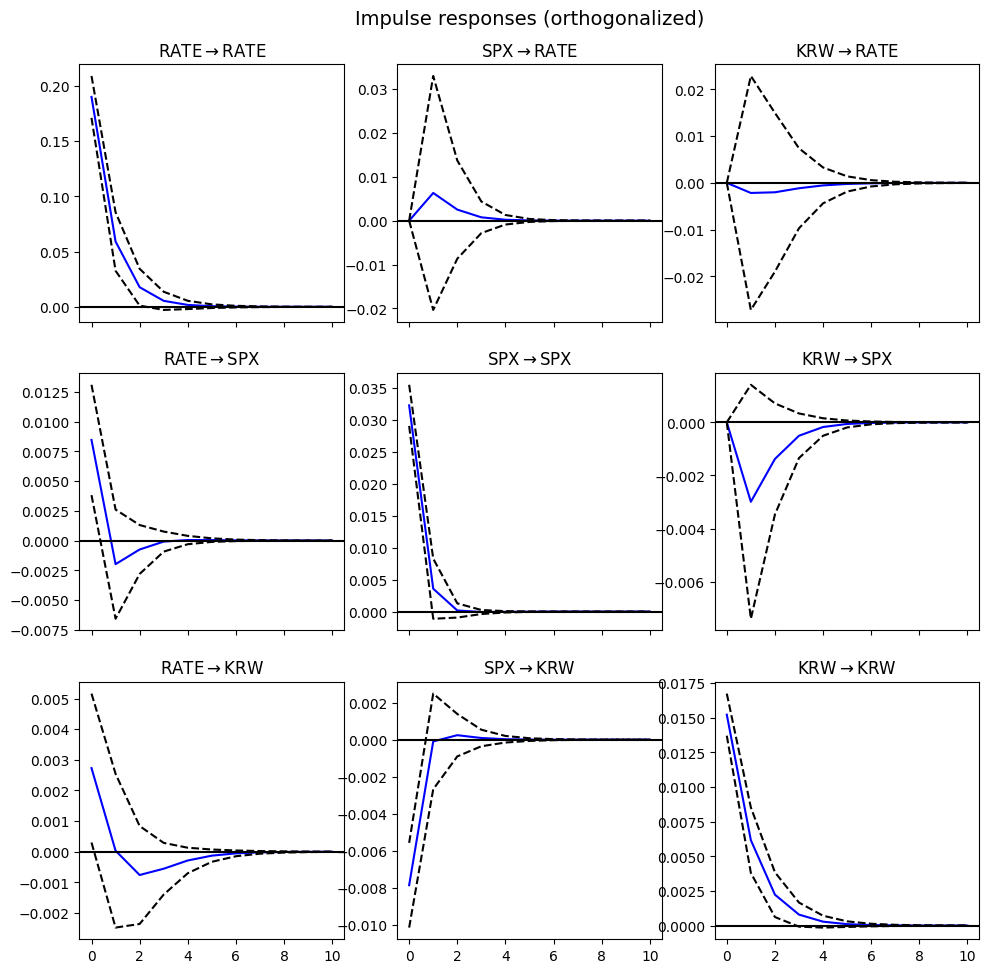

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt

# =========================================
# 1. 데이터 다운로드
# =========================================
tickers = ["^TNX", "^GSPC", "KRW=X"]

data = yf.download(tickers, start="2010-01-01")["Close"]

data = data[["^TNX", "^GSPC", "KRW=X"]]  # 🔥 핵심
data.columns = ["RATE", "SPX", "KRW"]

data = data.resample("M").mean()
data.index = data.index.to_period("M").to_timestamp()
data = data.head(195)

# 로그수익률 (stationary)
df = pd.DataFrame({
    "RATE": data["RATE"].diff(),          # 🔥 핵심
    "SPX": np.log(data["SPX"]).diff(),
    "KRW": np.log(data["KRW"]).diff()
}).dropna()

# =========================================
# 2. VAR 모델 적합
# =========================================
model = VAR(df)

lag_order = model.select_order(maxlags=10)
p = lag_order.aic  # AIC 기준

var_model = model.fit(p)

print(var_model.summary())

# =========================================
# 3. IRF 계산
# =========================================
irf = var_model.irf(10)  # 10 step

# =========================================
# 4. IRF plot
# =========================================
irf.plot(orth=True)
plt.show()

In [3]:
data

,RATE,SPX,KRW
Date,,,
2010-01-01,3.711053,1123.581582,1136.161906
2010-02-01,3.679263,1089.159989,1154.775000
2010-03-01,3.719261,1152.048690,1135.278262
2010-04-01,3.819333,1197.316185,1113.359086
2010-05-01,3.412750,1125.062006,1162.947626
...,...,...,...
2025-11-01,4.089789,6740.885768,1456.695001
2025-12-01,4.141409,6853.025457,1465.404097
2026-01-01,4.205150,6929.121973,1453.384766


In [4]:
df = df[["RATE", "SPX", "KRW"]]

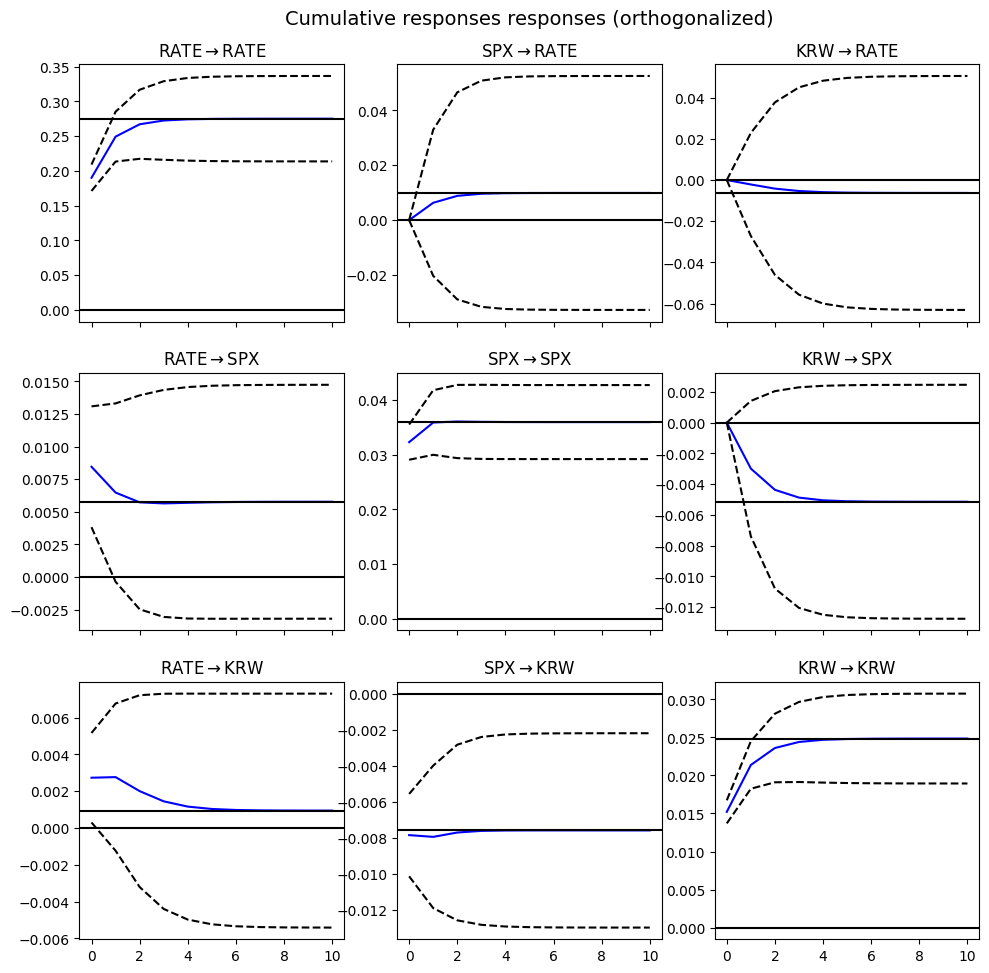

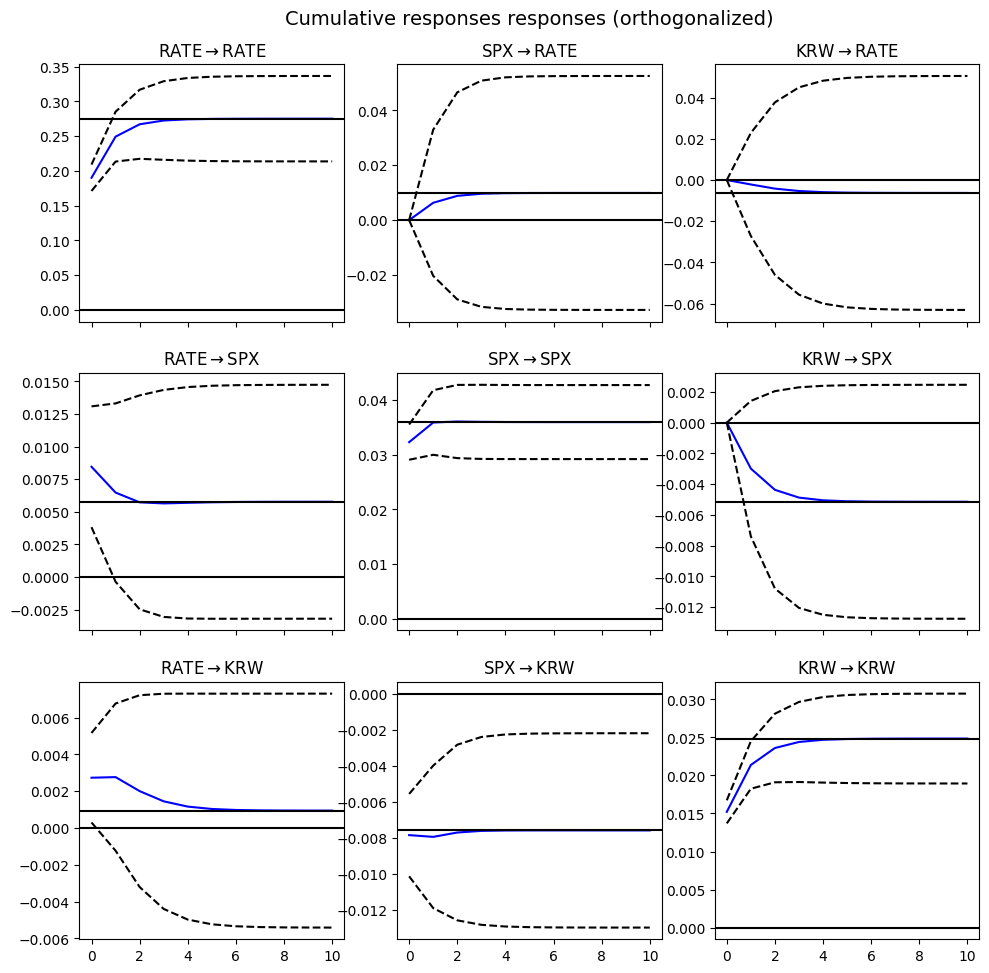

In [5]:
irf.plot_cum_effects(orth=True)

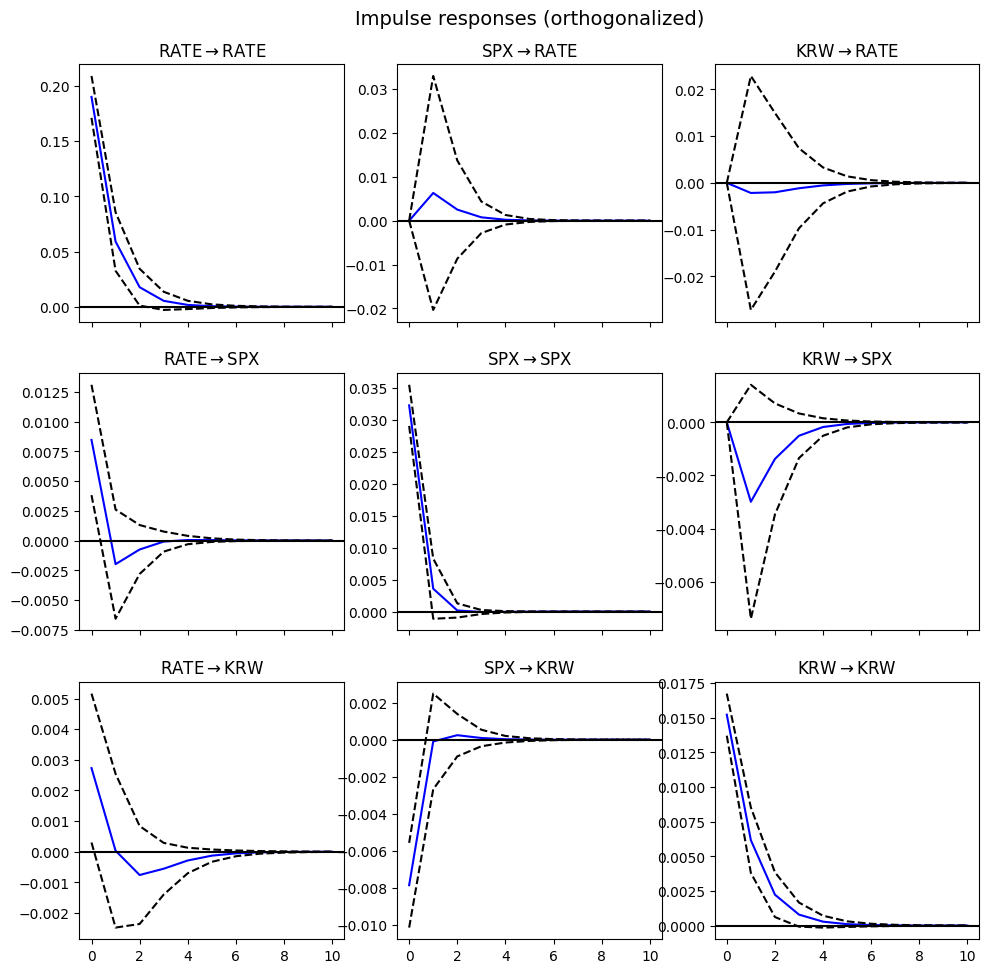

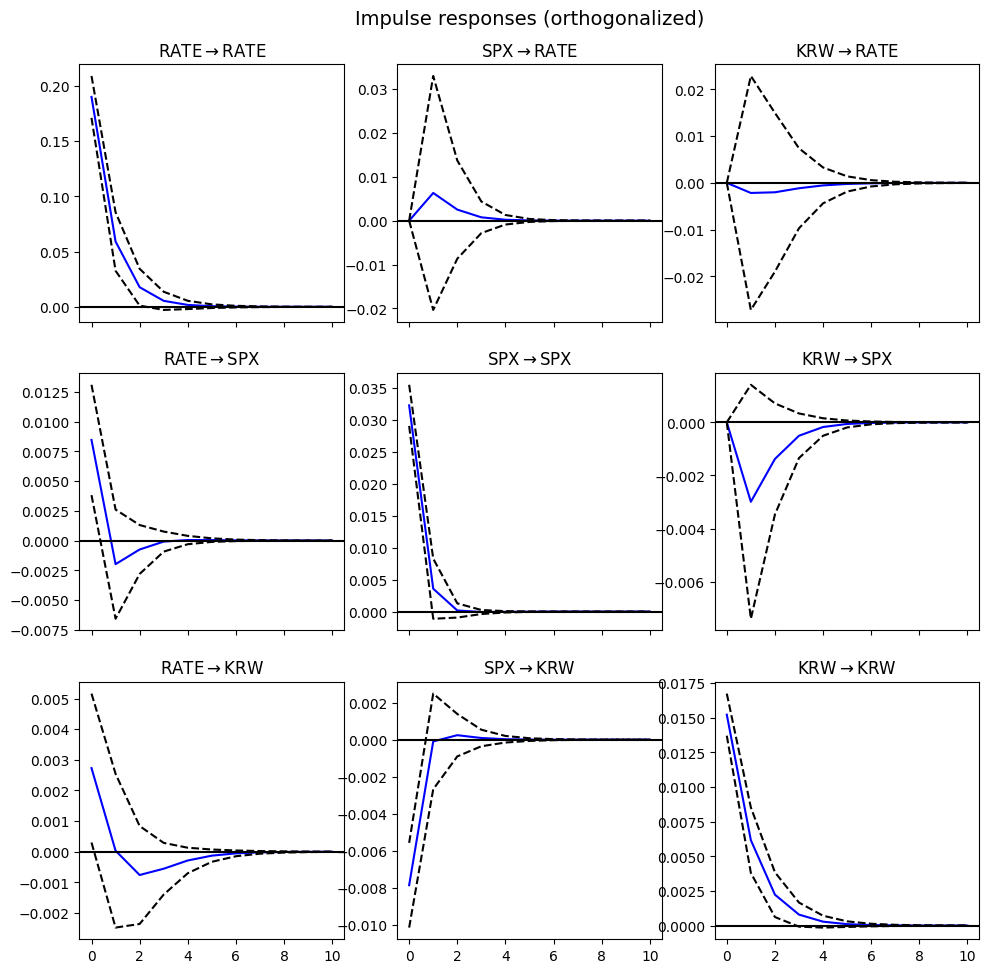

In [6]:
irf.plot(orth=True, signif=0.05)

In [7]:
data

,RATE,SPX,KRW
Date,,,
2010-01-01,3.711053,1123.581582,1136.161906
2010-02-01,3.679263,1089.159989,1154.775000
2010-03-01,3.719261,1152.048690,1135.278262
2010-04-01,3.819333,1197.316185,1113.359086
2010-05-01,3.412750,1125.062006,1162.947626
...,...,...,...
2025-11-01,4.089789,6740.885768,1456.695001
2025-12-01,4.141409,6853.025457,1465.404097
2026-01-01,4.205150,6929.121973,1453.384766


In [8]:
# IRF (returns 기준)
irf = var_model.irf(20)

# cumulative IRF
irf_cum = irf.cum_effects

In [9]:
# index 순서 확인
print(df.columns)

# 예: RATE shock → SPX 반응
response = irf_cum[:, df.columns.get_loc("SPX"), df.columns.get_loc("RATE")]


Index(['RATE', 'SPX', 'KRW'], dtype='object')


In [10]:
def get_level_irf(irf, df_cols, shock, response, scale=1.0):
    irf_cum = irf.cum_effects

    i = df_cols.get_loc(response)
    j = df_cols.get_loc(shock)

    log_irf = irf_cum[:, i, j]

    # 🔥 핵심: exp 전에 scaling
    log_irf_scaled = log_irf * scale

    level_irf = np.exp(log_irf_scaled)

    return level_irf

In [21]:
shock_std = var_model.resid["RATE"].std()

# 25bp = 0.25% = 0.0025
scale = 0.25 / shock_std
#scale = 0.12043887691377608 / shock_std

level_irf = get_level_irf(
    irf,
    df.columns,
    shock="RATE",
    response="SPX",
    scale=scale
)

In [22]:
horizon = len(level_irf)

price_path = np.insert(level_irf, 0, 1.0)  # 시작점 = 1

steps = np.arange(0, horizon+1)

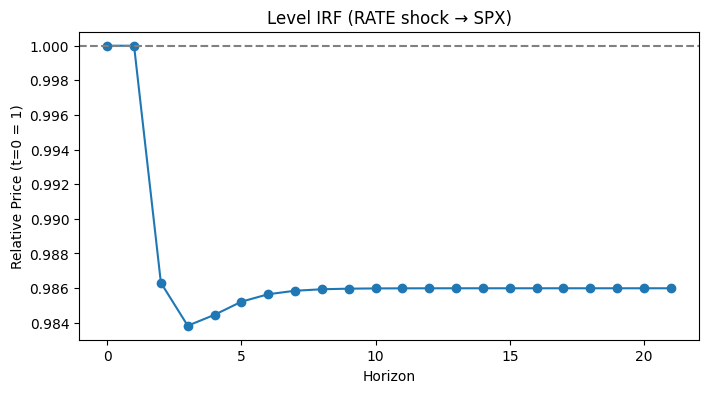

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(steps, price_path, marker='o')
plt.axhline(1.0, linestyle='--', color='gray')

plt.title("Level IRF (RATE shock → SPX)")
plt.ylabel("Relative Price (t=0 = 1)")
plt.xlabel("Horizon")

plt.show()

In [14]:
import numpy as np
np.std(data['RATE'][-12:])

0.12043887691377608

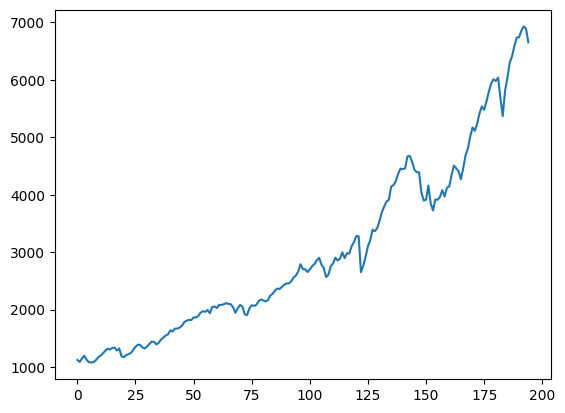

In [15]:
plt.plot(np.array(data['SPX']))

<Axes: xlabel='Date'>

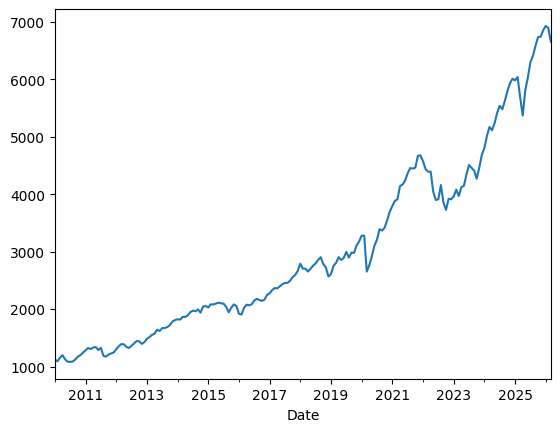

In [16]:
data['SPX'].plot()

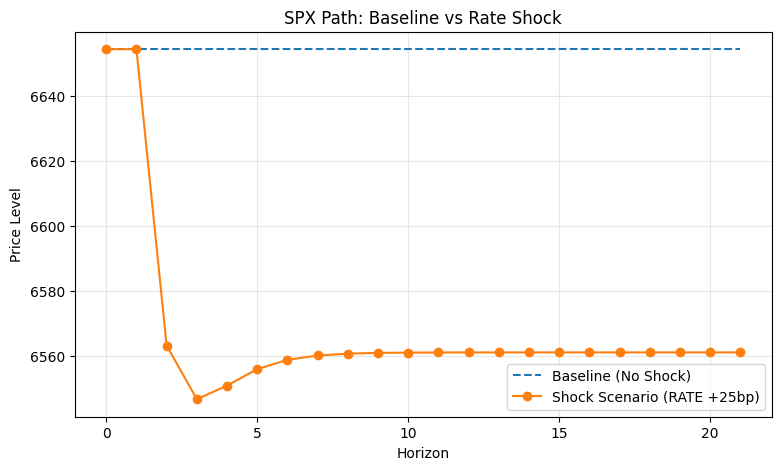

In [24]:
# =========================================
# 1. 마지막 실제 가격
# =========================================
last_price = data["SPX"].iloc[-1]

horizon = len(level_irf)

# =========================================
# 2. baseline 경로 (단순: flat)
# =========================================
baseline_path = np.full(horizon+1, last_price)

# =========================================
# 3. shock 경로
# =========================================
shock_ratio = np.insert(level_irf, 0, 1.0)
shock_path = baseline_path * shock_ratio

# =========================================
# 4. plot
# =========================================
steps = np.arange(0, horizon+1)

import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(steps, baseline_path, linestyle="--", label="Baseline (No Shock)")
plt.plot(steps, shock_path, marker="o", label="Shock Scenario (RATE +25bp)")

plt.title("SPX Path: Baseline vs Rate Shock")
plt.xlabel("Horizon")
plt.ylabel("Price Level")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

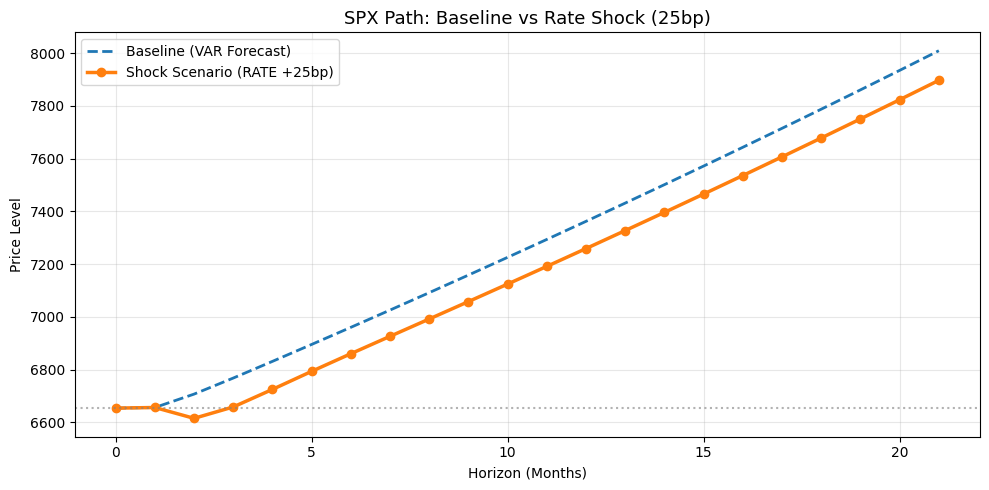

In [25]:
# =========================================
# 0. 준비
# =========================================
horizon = len(level_irf)
last_price = data["SPX"].iloc[-1]

# =========================================
# 1. VAR 기반 baseline forecast (핵심)
# =========================================
# 마지막 p개 관측치 (VAR 입력)
y_last = df.values[-var_model.k_ar:]

# VAR forecast (log-return space)
forecast = var_model.forecast(y_last, steps=horizon)

# SPX column index
spx_idx = df.columns.get_loc("SPX")

# SPX forecasted returns
spx_forecast = forecast[:, spx_idx]

# baseline price path 생성
baseline_path = [last_price]

for r in spx_forecast:
    baseline_path.append(baseline_path[-1] * np.exp(r))

baseline_path = np.array(baseline_path)

# =========================================
# 2. shock 경로 (IRF 반영)
# =========================================
shock_ratio = np.insert(level_irf, 0, 1.0)
shock_path = baseline_path * shock_ratio

# =========================================
# 3. 시각화
# =========================================
steps = np.arange(0, horizon + 1)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# baseline
plt.plot(steps, baseline_path,
         linestyle="--",
         linewidth=2,
         label="Baseline (VAR Forecast)")

# shock
plt.plot(steps, shock_path,
         marker="o",
         linewidth=2.5,
         label="Shock Scenario (RATE +25bp)")

# 스타일
plt.axhline(last_price, linestyle=":", color="gray", alpha=0.6)
plt.title("SPX Path: Baseline vs Rate Shock (25bp)", fontsize=13)
plt.xlabel("Horizon (Months)")
plt.ylabel("Price Level")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
#data.to_csv("irf_example_df.csv")